# **Library Imports & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import pickle
import warnings
from wordcloud import WordCloud
import time
from datetime import datetime
from google.colab import files
import io

# **Download Required NLTK Data**

In [2]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

#**Dataset Upload**

In [3]:
print("\nPlease upload your 'IMDB Dataset.csv' file.")
uploaded = files.upload()



Please upload your 'IMDB Dataset.csv' file.


Saving IMDB Dataset - IMDB Dataset.csv to IMDB Dataset - IMDB Dataset.csv


#**Dataset Loading**

In [5]:
file_name = next(iter(uploaded))

if file_name:
    print(f"\n '{file_name}' uploaded successfully!")
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print("Dataset loaded into DataFrame.")
else:
    print(" File upload failed. Please try again.")


 'IMDB Dataset - IMDB Dataset.csv' uploaded successfully!
Dataset loaded into DataFrame.


# **Exploratory Data Analysis (EDA)**
This block performs a deep dive into the dataset to understand its structure, uncover potential issues like duplicates, and visualize key characteristics.



 EXPLORATORY DATA ANALYSIS
 Dataset Shape: (50000, 2)
 Missing Values:
review       0
sentiment    0
dtype: int64

 Found 419 duplicate rows. Removing them...
Cleaned Dataset Shape: (49581, 2)


/tmp/ipython-input-2038216708.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='word_count', palette=colors, ax=axes[2])


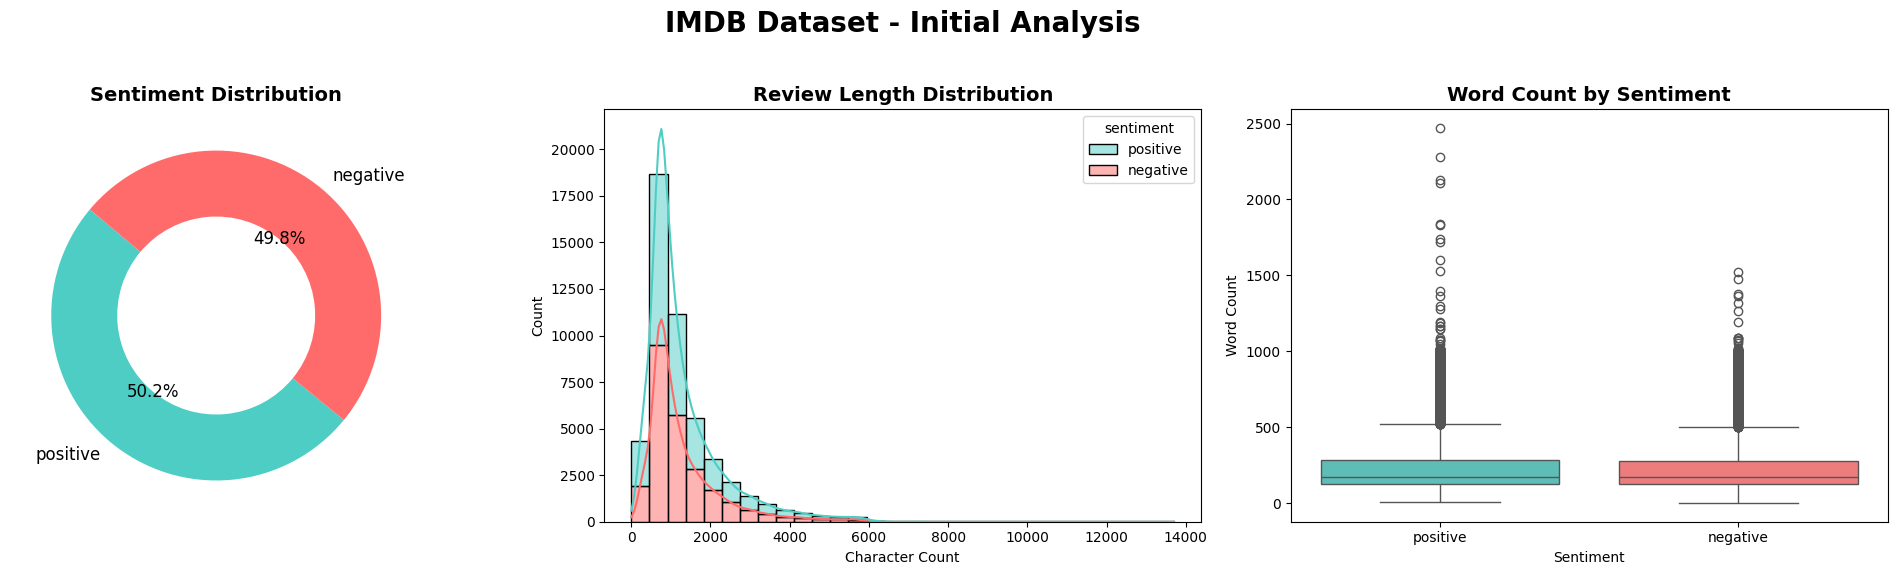

In [9]:
def comprehensive_eda(df):
    """Perform comprehensive exploratory data analysis with beautiful visualizations"""
    print("\n\n EXPLORATORY DATA ANALYSIS")
    print("=" * 50)

    # Basic statistics
    print(f" Dataset Shape: {df.shape}")
    print(f" Missing Values:\n{df.isnull().sum()}\n")

    # Handle duplicates
    duplicates = df.duplicated().sum()
    print(f" Found {duplicates} duplicate rows. Removing them...")
    df.drop_duplicates(inplace=True)
    print(f"Cleaned Dataset Shape: {df.shape}")

    # Add features for EDA
    df['review_length'] = df['review'].apply(len)
    df['word_count'] = df['review'].apply(lambda x: len(x.split()))

    # Visualize sentiment distribution and text features
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('IMDB Dataset - Initial Analysis', fontsize=20, fontweight='bold')

    # 1. Sentiment Distribution (Pie Chart)
    sentiment_counts = df['sentiment'].value_counts()
    colors = ['#4ECDC4', '#FF6B6B']
    axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
              startangle=140, colors=colors, wedgeprops=dict(width=0.4), textprops={'fontsize': 12})
    axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')

    # 2. Review Length Distribution by Sentiment
    sns.histplot(data=df, x='review_length', hue='sentiment', multiple='stack',
                 palette=colors, ax=axes[1], bins=30, kde=True)
    axes[1].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Character Count')

    # 3. Word Count Distribution by Sentiment
    sns.boxplot(data=df, x='sentiment', y='word_count', palette=colors, ax=axes[2])
    axes[2].set_title('Word Count by Sentiment', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Sentiment')
    axes[2].set_ylabel('Word Count')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return df

df = comprehensive_eda(df)

# **Advanced Text Preprocessing**
Here I defines and applies a sophisticated cleaning pipeline to transform raw review text into a standardized format suitable for machine learning.

In [6]:
def preprocess_text(text):
    """A robust function to clean and preprocess text data."""
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Remove single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    # Tokenize and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [w for w in text.split() if not w in stop_words]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    lemmed_words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(lemmed_words)

print("\n\n ADVANCED TEXT PREPROCESSING")
print("=" * 50)

# Show a before-and-after example
sample_text = df['review'].iloc[0]
print(f" Original Text Example:\n'{sample_text[:200]}...'")

# Apply the preprocessing function
df['cleaned_review'] = df['review'].apply(preprocess_text)
cleaned_sample = df['cleaned_review'].iloc[0]
print(f"\n Cleaned Text Example:\n'{cleaned_sample[:200]}...'")

# Encode sentiment labels
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("\n  Sentiments encoded to 1 (positive) and 0 (negative).")



 ADVANCED TEXT PREPROCESSING
 Original Text Example:
'One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...'

 Cleaned Text Example:
'one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch reg...'

  Sentiments encoded to 1 (positive) and 0 (negative).


# **Data Splitting & Vectorization**
Here I splits the data into training and testing sets and then converts the cleaned text into numerical vectors using TF-IDF.

In [7]:
print("\n\n DATA SPLITTING & VECTORIZATION")
print("=" * 50)

# Define features (X) and target (y)
X = df['cleaned_review']
y = df['sentiment']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")

# Initialize and fit the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Text vectorized using TF-IDF. Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")



 DATA SPLITTING & VECTORIZATION
Data split: 40000 training samples, 10000 testing samples.
Text vectorized using TF-IDF. Vocabulary size: 5000


# **Model Training & Comparison**
Trains several different classification models to identify which algorithm performs best on this specific task.

In [8]:
print("\n\n MODEL TRAINING & COMPARISON")
print("=" * 50)

from sklearn.ensemble import RandomForestClassifier

# Define models to train
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    print(f" Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'f1_score': f1, 'model': model}
    print(f"{name} -> Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

# Find the best model based on F1-score
best_model_name = max(results, key=lambda name: results[name]['f1_score'])
best_model = results[best_model_name]['model']
print(f"\n Best performing model: {best_model_name}")




 MODEL TRAINING & COMPARISON
 Training Naive Bayes...
Naive Bayes -> Accuracy: 0.8611, F1-Score: 0.8634
 Training Logistic Regression...
Logistic Regression -> Accuracy: 0.8917, F1-Score: 0.8928
 Training Random Forest...
Random Forest -> Accuracy: 0.8534, F1-Score: 0.8522

 Best performing model: Logistic Regression


# **Hyperparameter Tuning**
Here I fine-tunes the best model from the previous step by systematically searching for its optimal settings, further boosting performance.

In [9]:
print(f"\n\n HYPERPARAMETER TUNING FOR {best_model_name}")
print("=" * 50)

# Define parameter grid (example for Logistic Regression)
# Adjust this grid based on which model performed best
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2']
    }
elif best_model_name == 'Naive Bayes':
    param_grid = {'alpha': [0.1, 0.5, 1.0]}
elif best_model_name == 'SVM':
    param_grid = {'C': [0.1, 1, 10]}

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(best_model, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_tfidf, y_train)

# Get the best, tuned model
best_tuned_model = grid_search.best_estimator_
print(f"\n Best Parameters Found: {grid_search.best_params_}")
print(f" Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")



 HYPERPARAMETER TUNING FOR Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits

 Best Parameters Found: {'C': 1, 'penalty': 'l2'}
 Best Cross-Validation F1-Score: 0.8877


# **Final Model Evaluation**
provides a comprehensive evaluation of the final, tuned model, including a confusion matrix and a detailed classification report.



 FINAL MODEL EVALUATION
 Classification Report:

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



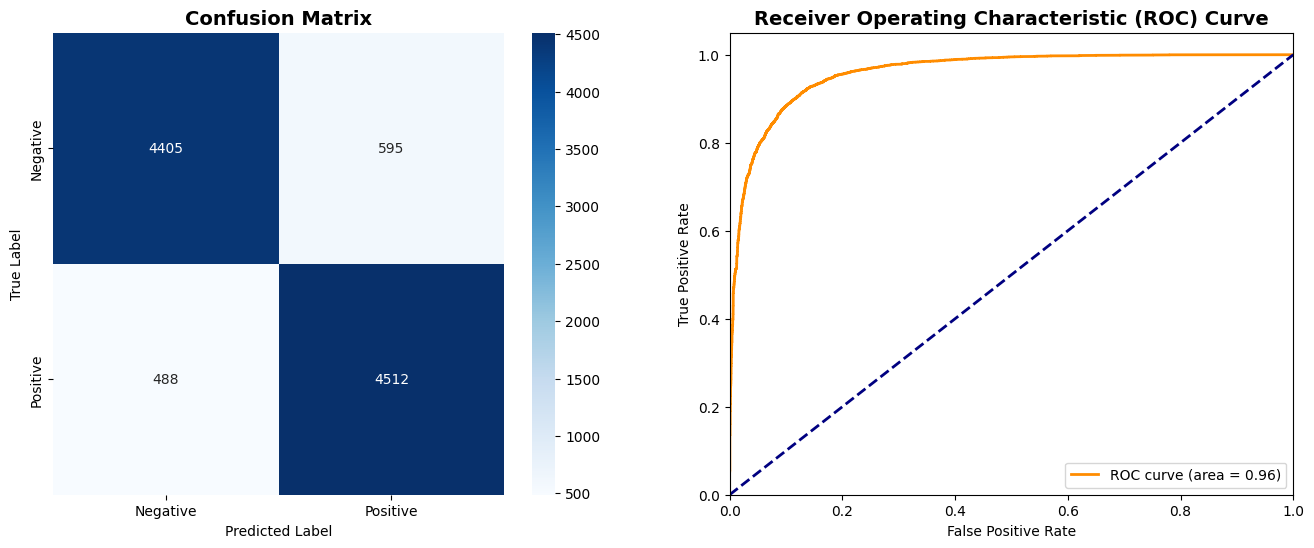

In [10]:
print("\n\n FINAL MODEL EVALUATION")
print("=" * 50)

# Predictions with the tuned model
y_pred_final = best_tuned_model.predict(X_test_tfidf)
y_pred_proba_final = best_tuned_model.predict_proba(X_test_tfidf)[:, 1]

# Display classification report
print(" Classification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

# Plot Confusion Matrix and ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
plt.show()

# **Model Interpretability & Feature Importance**
This enhanced block visualizes the most influential words the model uses for its predictions, offering clear insights into its decision-making process.



 MODEL INTERPRETABILITY


/tmp/ipython-input-2648345891.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive, x='importance', y='feature', ax=ax1, palette='Greens_r')
/tmp/ipython-input-2648345891.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_negative, x='importance', y='feature', ax=ax2, palette='Reds_r')


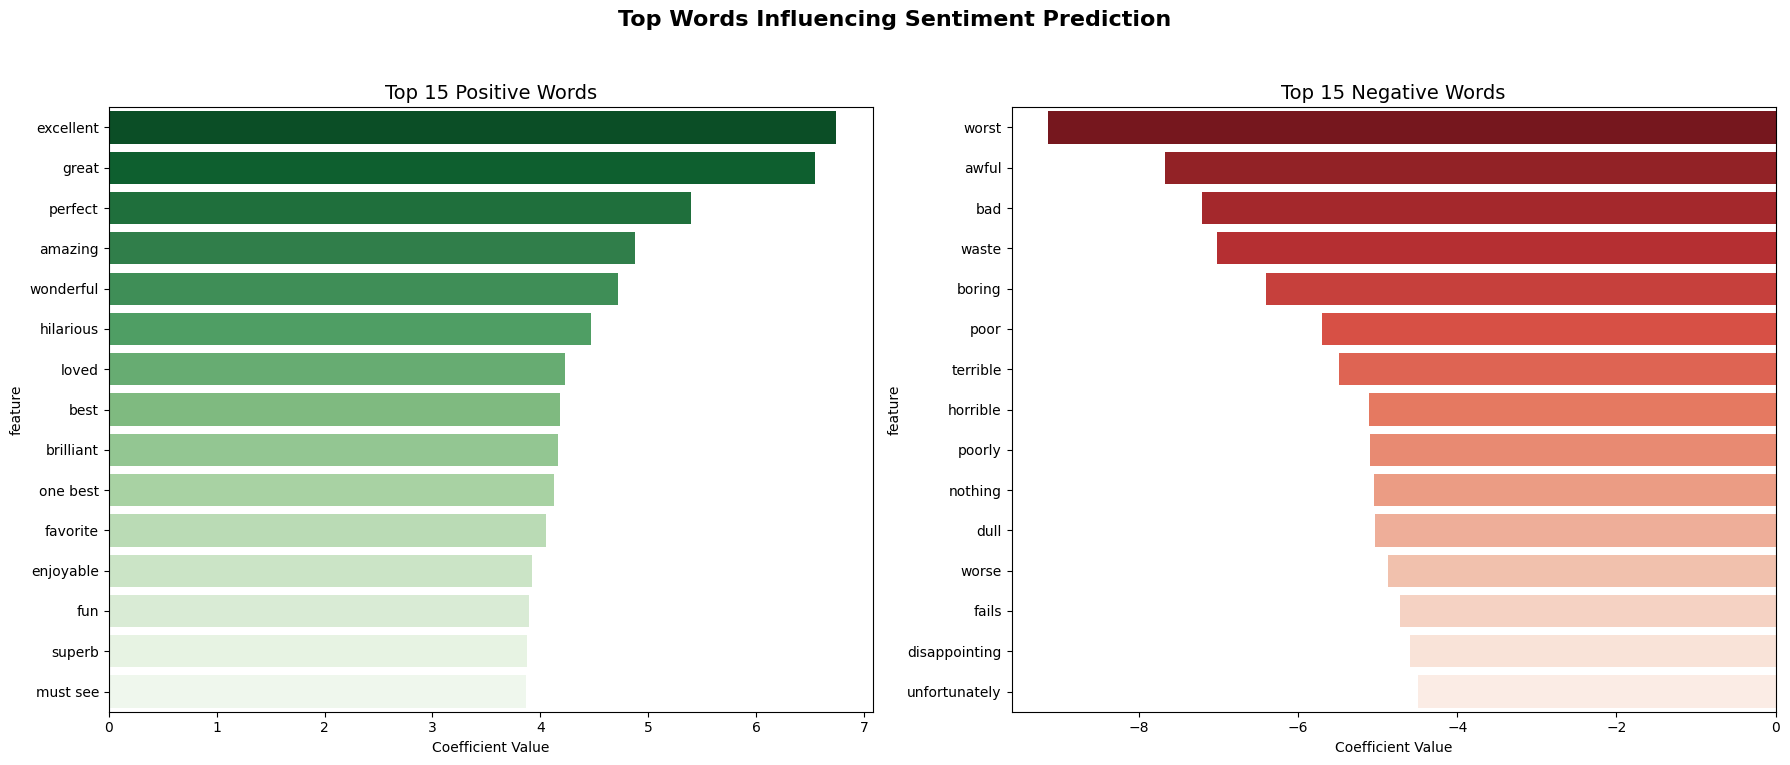

In [11]:
print("\n\n MODEL INTERPRETABILITY")
print("=" * 50)

# This works best for models with 'coef_' attribute like Logistic Regression or Linear SVM
if hasattr(best_tuned_model, 'coef_'):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    coefs = best_tuned_model.coef_[0]
    feature_importance = pd.DataFrame({'feature': feature_names, 'importance': coefs})

    # Get top 15 positive and negative words
    top_positive = feature_importance.nlargest(15, 'importance')
    top_negative = feature_importance.nsmallest(15, 'importance')

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Top Words Influencing Sentiment Prediction', fontsize=16, fontweight='bold')

    sns.barplot(data=top_positive, x='importance', y='feature', ax=ax1, palette='Greens_r')
    ax1.set_title('Top 15 Positive Words', fontsize=14)
    ax1.set_xlabel('Coefficient Value')

    sns.barplot(data=top_negative, x='importance', y='feature', ax=ax2, palette='Reds_r')
    ax2.set_title('Top 15 Negative Words', fontsize=14)
    ax2.set_xlabel('Coefficient Value')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Model {best_model_name} does not have a 'coef_' attribute for direct feature importance.")

# **Error Analysis**
This critical  step examines the model's mistakes, helping to understand where it struggles and why.

In [12]:
print("\n\n ERROR ANALYSIS")
print("=" * 50)

# Create a DataFrame with test data, true labels, and predictions
error_df = pd.DataFrame({
    'review': X_test,
    'true_sentiment': y_test,
    'predicted_sentiment': y_pred_final
})

# Isolate the incorrect predictions
misclassified = error_df[error_df['true_sentiment'] != error_df['predicted_sentiment']]
print(f"Found {len(misclassified)} misclassified reviews out of {len(X_test)}.")

# Display some examples of misclassified reviews

# False Positives (Predicted Positive, Actually Negative)
print("\n--- False Positives (Predicted Positive, but was Negative) ---\n")
fp_examples = misclassified[misclassified['true_sentiment'] == 0].head(2)
for index, row in fp_examples.iterrows():
    print(f"Review: {row['review'][:300]}...")
    print("-" * 20)

# False Negatives (Predicted Negative, Actually Positive)
print("\n--- False Negatives (Predicted Negative, but was Positive) ---\n")
fn_examples = misclassified[misclassified['true_sentiment'] == 1].head(2)
for index, row in fn_examples.iterrows():
    print(f"Review: {row['review'][:300]}...")
    print("-" * 20)



 ERROR ANALYSIS
Found 1083 misclassified reviews out of 10000.

--- False Positives (Predicted Positive, but was Negative) ---

Review: little quentin seems mastered art cake eating usual pure sadistic display explained clever thought provoking way sending violence back audience face sure mr tarantino violence baaad sadism baaad well worth wading make point brilliant juvenile part audience may well clever enough follow smart referen...
--------------------
Review: film listed made film available something weird video driver ed scare film vol one thing version color swv disc earlier version film made w wlwt television channel cincinnati either way film notorious however unlike driver ed film intended television broadcast viewing general public thus level carna...
--------------------

--- False Negatives (Predicted Negative, but was Positive) ---

Review: almost documentary look enterprising boy life body shop area outside new york real way real lighting real sound less editing whole 

# **Saving the Final Model**
I saves the trained model and the vectorizer, so anyone can easily load and use them later without retraining.

In [13]:
print("\n\n SAVING THE FINAL MODEL")
print("=" * 50)

# Define file names
model_filename = f'{best_model_name}_tuned_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

# Save the model
with open(model_filename, 'wb') as f:
    pickle.dump(best_tuned_model, f)
print(f" Best model saved as '{model_filename}'")

# Save the vectorizer
with open(vectorizer_filename, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f" Vectorizer saved as '{vectorizer_filename}'")

print("\n Project Complete!")



 SAVING THE FINAL MODEL
 Best model saved as 'Logistic Regression_tuned_model.pkl'
 Vectorizer saved as 'tfidf_vectorizer.pkl'

 Project Complete!
